### Logistic Regression Classification

**What is Logistic Regression?**
- Logistic Regression is a supervised machine learning algorithm used for classification problems.
- It predicts the probability that a given input belongs to a particular class.
- Uses the sigmoid function to output probabilities between 0 and 1.

**Type of ML Problem:**
- Supervised Learning – Classification

**Real-world Applications:**
- Email spam detection
- Customer churn prediction
- Medical diagnosis (disease prediction)
- Credit risk scoring

**Why Logistic Regression is useful:**
- Simple and interpretable
- Fast to train and deploy
- Works well with linearly separable data

**Importing Libraries**

In [1]:
import pandas as pd          # Data manipulation
import numpy as np           # Numerical operations
import matplotlib.pyplot as plt  # Visualization
import seaborn as sns        # Statistical plotting

# ML models and tools
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

# Model explainability
import shap

# Saving models
import joblib

**Load dataset**

In [2]:
from sklearn.datasets import load_breast_cancer

In [3]:
data = load_breast_cancer()

In [4]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

In [5]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Dataset info**

In [6]:
print("Dataset shape:", X.shape)

Dataset shape: (569, 30)


In [7]:
print("\nFirst 5 rows:\n", X.head())


First 5 rows:
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter

In [8]:
print("\nTarget distribution:\n", y.value_counts())


Target distribution:
 target
1    357
0    212
Name: count, dtype: int64


In [9]:
print("\nDataset description:\n", data.DESCR)


Dataset description:
 .. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 i

**Exploratory Data Analysis (EDA)**

In [10]:
# Check missing values
X.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

In [11]:
# Statistical summary
print("\nStatistical summary:\n", X.describe())


Statistical summary:
        mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000           

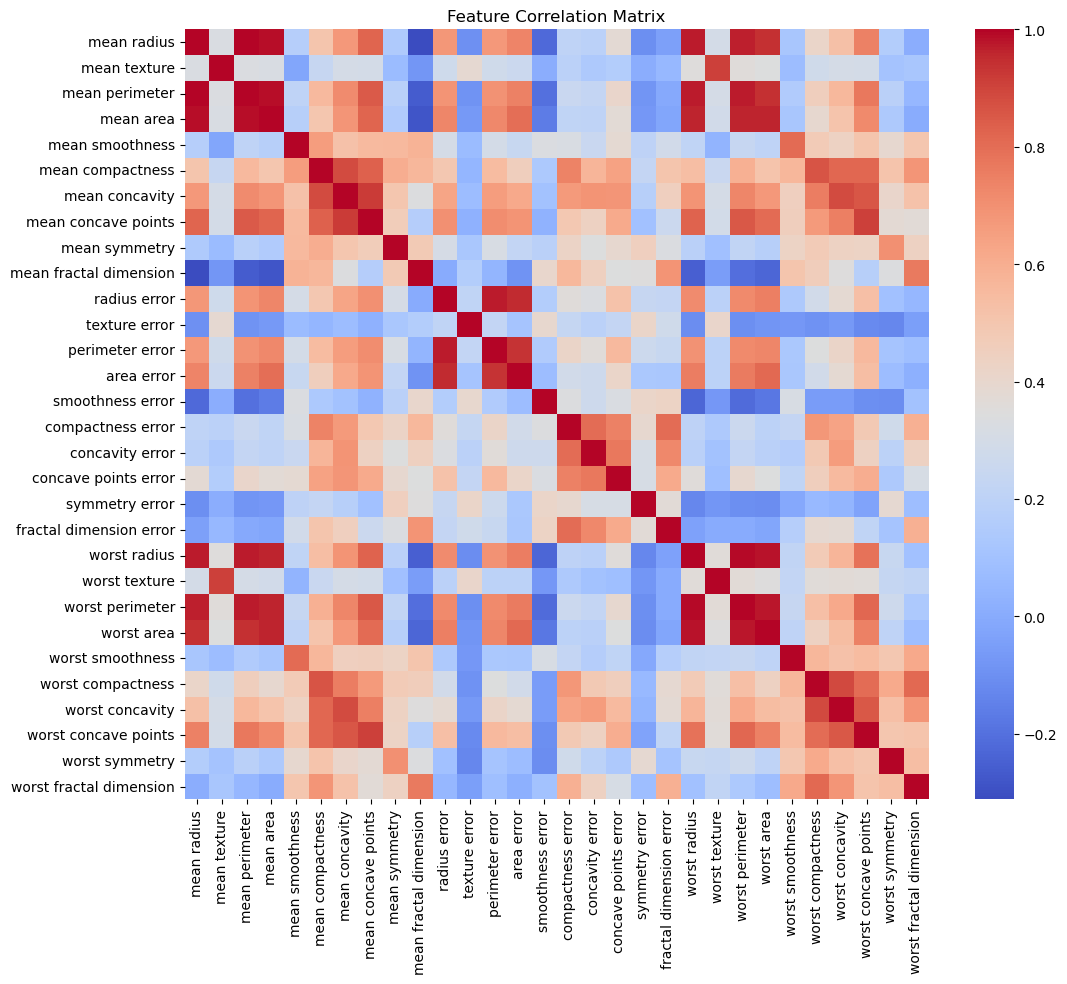

In [12]:
# Correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(X.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

**Data Preprocessing**

In [13]:
# Impute missing values if any (not needed for breast cancer dataset)
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


In [14]:
# Feature scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)

**Train-Test Split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,  # Features
    y,         # Target
    test_size=0.2,   # 20% test data
    random_state=42, # For reproducibility
    stratify=y       # Preserve class distribution
)

In [16]:
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (455, 30), Test shape: (114, 30)


**Model Creation & Training**

In [17]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),           # Feature scaling
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])


In [18]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

**Hyperparameter Tuning**

In [19]:
param_grid = {
    'classifier__penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['saga'],  # saga supports l1/l2/elasticnet
    'classifier__l1_ratio': [0, 0.5, 1]  # only used if penalty='elasticnet'
}

In [20]:
# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,       # The pipeline containing scaler + classifier
    param_grid=param_grid,    # Hyperparameter options
    cv=5,                     # 5-fold cross-validation
    scoring='accuracy',       # Evaluation metric
    n_jobs=-1                 # Use all cores
)

In [24]:
grid_search.fit(X_train, y_train)  # Must include BOTH X_train and y_train

E:\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
60 fits failed out of a total of 240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
32 fits failed with the following error:
Traceback (most recent call last):
  File "E:\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "E:\anaconda\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "E:\anaconda\Lib\site-packages\sklearn\pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
    ~~~~~~~~~~~~

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__l1_ratio': [0, 0.5, 1],
                         'classifier__penalty': ['l1', 'l2', 'elasticnet',
                                                 'none'],
                         'classifier__solver': ['saga']},
             scoring='accuracy')

In [25]:
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

best_model = grid_search.best_estimator_

Best parameters: {'classifier__C': 0.1, 'classifier__l1_ratio': 0.5, 'classifier__penalty': 'elasticnet', 'classifier__solver': 'saga'}
Best cross-validation score: 0.9824175824175825


**Model Evaluation**

In [26]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [27]:
# Classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

In [28]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Accuracy: 0.9649
Precision: 0.9595
Recall: 0.9861
F1 Score: 0.9726
ROC-AUC: 0.9954


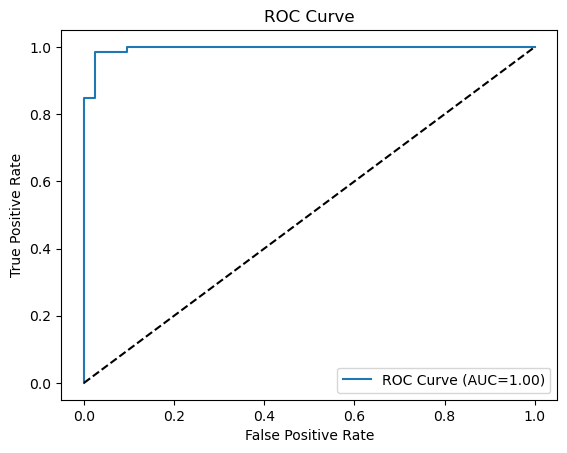

In [29]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC={roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

**Model Explainability**

E:\anaconda\Lib\site-packages\shap\explainers\_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


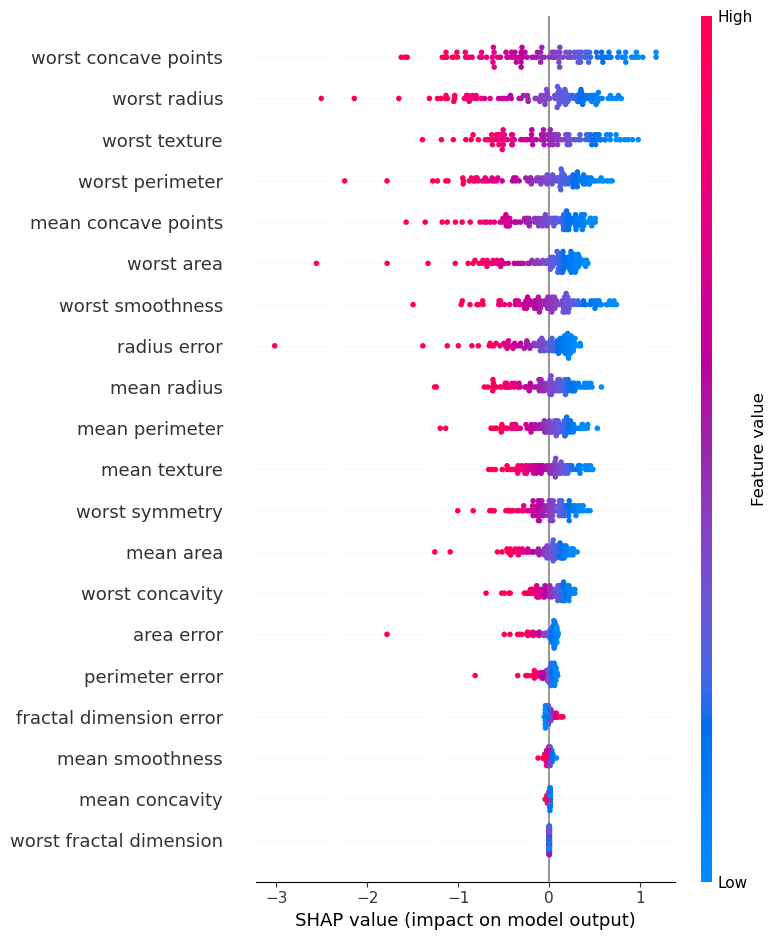

In [30]:
explainer = shap.LinearExplainer(best_model.named_steps['classifier'], X_train, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X.columns)

**Final Model Insights**

- Most important features: determined from SHAP plot
- Model seems to generalize well (train vs test accuracy comparable)
- Possible improvements:
    - Feature selection
    - Regularization tuning
    - Try ensemble methods

**Saving the Model**

In [31]:
joblib.dump(best_model, 'logistic_regression_model.pkl')
print("Model saved successfully!")

Model saved successfully!


# Logistic Regression Theory

## 1. Algorithm Overview
- Logistic Regression is a **supervised machine learning algorithm** used for **classification problems**.  
- It predicts the probability of a **binary outcome** (0 or 1) based on input features.  
- Unlike linear regression, which outputs continuous values, logistic regression uses a **sigmoid function** to output probabilities between 0 and 1:  

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

- Based on a threshold (commonly 0.5), the probability is converted into a class label.  

**Real-world applications:**
- Email spam detection  
- Customer churn prediction  
- Disease diagnosis  
- Credit risk scoring  



## 2. Mathematical Intuition
- For input features $(X = [x_1, x_2, ..., x_n]) $ and coefficients $(w = [w_1, w_2, ..., w_n])$, the probability of class 1 is:  

$$
P(y=1|X) = \sigma(w^T X + b) = \frac{1}{1 + e^{-(w^T X + b)}}
$$

- **Decision rule:**  

$$
\hat{y} = 
\begin{cases} 
1 & \text{if } P(y=1|X) \ge 0.5 \\
0 & \text{if } P(y=1|X) < 0.5
\end{cases}
$$

- **Loss function:** Logistic regression minimizes the **binary cross-entropy (log loss)**:  

$$
L = -\frac{1}{m} \sum_{i=1}^{m} [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]
$$

- Optimized using **gradient descent** or solvers like `liblinear`, `saga`, or `lbfgs`.  



## 3. When to Use This Model
- Binary classification problems  
- Small to medium datasets  
- Linearly separable data (or approximate linearity)  
- When **interpretability** is important  



## 4. Advantages
- Simple and interpretable  
- Probabilistic output (can be used for decision thresholds)  
- Fast to train and deploy  
- Works well as a baseline model  



## 5. Disadvantages
- Cannot capture **non-linear relationships** unless features are transformed  
- Sensitive to **multicollinearity** between features  
- Limited performance on very complex datasets  
- Assumes **linear decision boundary**  



## 6. Important Hyperparameters
| Hyperparameter | Description | Typical Values |
|----------------|------------|----------------|
| `penalty` | Regularization type | `'l1'`, `'l2'`, `'elasticnet'`, `'none'` |
| `C` | Inverse of regularization strength | `0.01, 0.1, 1, 10` |
| `solver` | Optimization algorithm | `'liblinear'`, `'saga'`, `'lbfgs'` |
| `max_iter` | Maximum iterations | `100-1000` |
| `l1_ratio` | ElasticNet mixing parameter | `0 (l2) - 1 (l1)` |


## 7. Practical Tuning Tips
- **Scale features** (StandardScaler or MinMaxScaler) for better convergence  
- Use **cross-validation** for robust hyperparameter selection  
- Try **feature engineering** or **polynomial features** to capture non-linear relationships  
- Use **regularization** (`C`, `penalty`) to prevent overfitting  
- Start with **simple logistic regression** as a baseline before moving to more complex models  



## 8. Model Interpretation
- Coefficients \(w_i\) indicate the **log-odds change** for a unit increase in the feature.  
- Positive \(w_i\) → increases probability of class 1  
- Negative \(w_i\) → decreases probability of class 1  
- Use tools like **SHAP**, **permutation importance**, or **partial dependence plots** for detailed interpretation  
